# Anomaly Detection  Smart Anomaly Alert
Notebook ini membangun model Isolation Forest untuk mendeteksi transaksi pengeluaran
yang secara statistik tidak wajar dibandingkan pola historis warung.

Model dilatih per kategori pengeluaran (HPP, Operasional, Overhead) agar baseline
normal setiap kategori tidak tercampur.



## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import json
import warnings
import os

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)

print('Library berhasil diimport.')

Library berhasil diimport.



## 2. Load Data

In [2]:
df_transaksi = pd.read_csv('./dataset_bersih/transaksi_bersih.csv', parse_dates=['tanggal'])

print(f'Total baris: {len(df_transaksi):,}')
df_transaksi.head()

Total baris: 13,486


,id_transaksi,id_warung,id_produk,tanggal,jam_transaksi,jenis,kategori,nominal,qty,metode_bayar,catatan,jenis_bersih,jam_missing,hari_dalam_minggu,nama_hari,bulan,minggu_ke,is_awal_bulan,is_weekend,jam_encoded
0,329D1583-136,WRG-005,PRD-005-028,2026-07-01,1900-01-01 08:44:50,Pemasukan,Penjualan,27000.0000,3.0000,Cash,NaN,Pemasukan,0,2,Wednesday,2026-07,2026-06-29/2026-07-05,1,0,8.0000
1,D0ECC4C8-9D6,WRG-005,PRD-005-013,2026-05-01,1900-01-01 20:11:25,Pemasukan,Penjualan,5000.0000,1.0000,Cash,NaN,Pemasukan,0,4,Friday,2026-05,2026-04-27/2026-05-03,1,0,20.0000
2,714AE3C0-5DE,WRG-003,PRD-003-015,2026-10-01,1900-01-01 17:50:52,Pemasukan,Penjualan,5000.0000,1.0000,QRIS,NaN,Pemasukan,0,3,Thursday,2026-10,2026-09-28/2026-10-04,1,0,17.0000
3,26088624-7A2,WRG-005,PRD-005-028,2026-03-02,1900-01-01 08:05:43,Pemasukan,Penjualan,9000.0000,1.0000,Transfer,NaN,Pemasukan,0,0,Monday,2026-03,2026-03-02/2026-03-08,1,0,8.0000
4,55FF5DBF-A07,WRG-001,PRD-001-015,2026-06-02,1900-01-01 17:26:48,Pemasukan,Penjualan,22000.0000,1.0000,QRIS,NaN,Pemasukan,0,1,Tuesday,2026-06,2026-06-01/2026-06-07,1,0,17.0000



## 3. Persiapan Data Pengeluaran

In [3]:
# Isolation Forest dilatih hanya pada transaksi pengeluaran
# Baris dengan jam_transaksi kosong dieksklusi (jam_encoded dibutuhkan sebagai fitur)
df_keluar = df_transaksi[
    (df_transaksi['jenis'] == 'Pengeluaran') &
    (df_transaksi['jam_encoded'].notna()) &
    (df_transaksi['nominal'] > 0)
].copy()

print(f'Baris pengeluaran untuk training: {len(df_keluar):,}')
print(f'\nDistribusi kategori:')
print(df_keluar['kategori'].value_counts())

Baris pengeluaran untuk training: 573

Distribusi kategori:
kategori
HPP            399
Operasional    104
Overhead        70
Name: count, dtype: int64



## 4. Feature Engineering

In [4]:
# Label encoding untuk kategori
le_kategori = LabelEncoder()
df_keluar['kategori_encoded'] = le_kategori.fit_transform(df_keluar['kategori'])

# Rolling mean 7 hari per kategori per warung sebagai baseline
df_keluar = df_keluar.sort_values(['id_warung', 'kategori', 'tanggal'])
df_keluar['rolling_mean_7d'] = df_keluar.groupby(
    ['id_warung', 'kategori']
)['nominal'].transform(lambda x: x.rolling(7, min_periods=1).mean())

# Rasio nominal terhadap rolling mean (seberapa jauh dari baseline)
df_keluar['rasio_vs_baseline'] = df_keluar['nominal'] / df_keluar['rolling_mean_7d'].replace(0, np.nan)
df_keluar['rasio_vs_baseline'] = df_keluar['rasio_vs_baseline'].fillna(1.0)

print('Fitur yang digunakan untuk Isolation Forest:')
fitur_cols = ['nominal', 'kategori_encoded', 'hari_dalam_minggu', 'jam_encoded', 'rolling_mean_7d', 'rasio_vs_baseline']
print(df_keluar[fitur_cols].describe())

Fitur yang digunakan untuk Isolation Forest:
           nominal  kategori_encoded  hari_dalam_minggu  jam_encoded  \
count     573.0000          573.0000           573.0000     573.0000   
mean   643058.2862            0.4258             2.9895       8.6649   
std    445301.0605            0.6998             1.9691       2.7174   
min      8577.0000            0.0000             0.0000       6.0000   
25%    254935.0000            0.0000             1.0000       7.0000   
50%    625371.0000            0.0000             3.0000       8.0000   
75%    989285.0000            1.0000             5.0000       9.0000   
max   1495464.0000            2.0000             6.0000      14.0000   

       rolling_mean_7d  rasio_vs_baseline  
count         573.0000           573.0000  
mean       647399.5311             0.9926  
std        324736.8656             0.4684  
min         15561.0000             0.0972  
25%        555571.8571             0.6231  
50%        701813.0000             0.9790 


## 5. Eksplorasi Distribusi Pengeluaran per Kategori

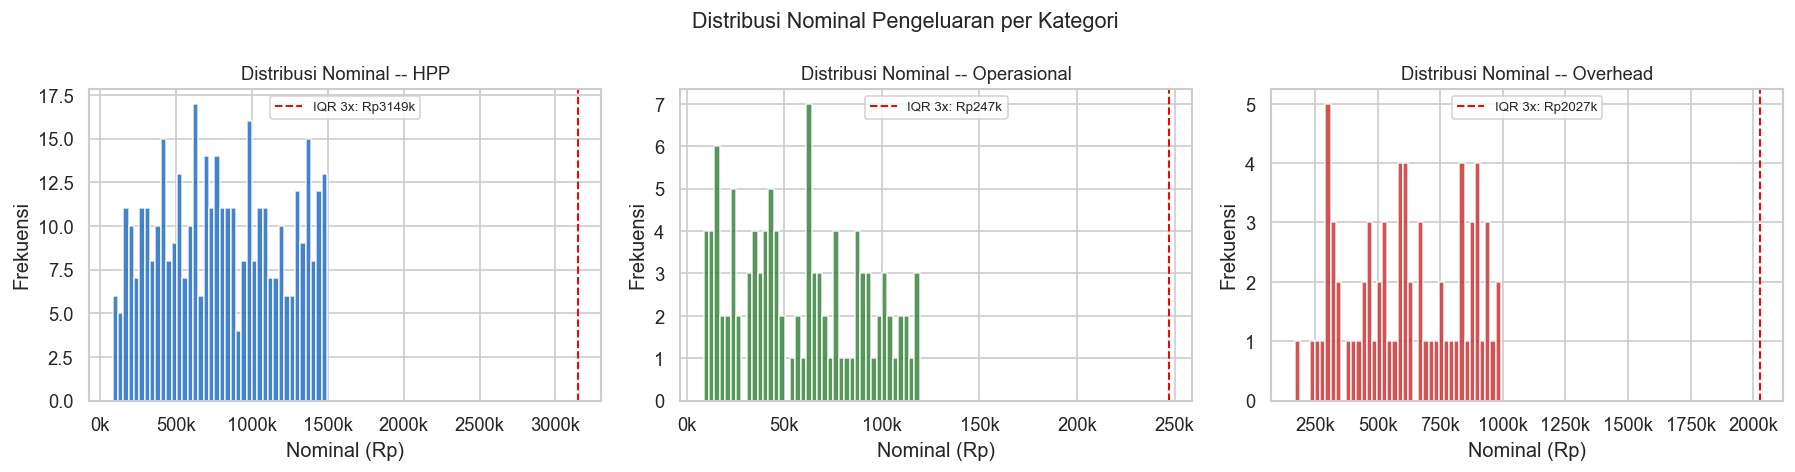

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kategori_list = ['HPP', 'Operasional', 'Overhead']
colors = ['#1565C0', '#2E7D32', '#C62828']

for i, (kat, col) in enumerate(zip(kategori_list, colors)):
    data = df_keluar[df_keluar['kategori'] == kat]['nominal']
    axes[i].hist(data, bins=40, color=col, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Distribusi Nominal -- {kat}', fontsize=11)
    axes[i].set_xlabel('Nominal (Rp)')
    axes[i].set_ylabel('Frekuensi')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

    # Tandai batas outlier IQR
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    upper = Q3 + 3 * (Q3 - Q1)
    axes[i].axvline(x=upper, color='red', linestyle='--', linewidth=1.2, label=f'IQR 3x: Rp{upper/1000:.0f}k')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Nominal Pengeluaran per Kategori', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Training Isolation Forest per Kategori

In [6]:
# Isolation Forest dilatih terpisah per kategori agar threshold anomali
# disesuaikan dengan distribusi masing-masing kategori
# contamination = estimasi proporsi outlier yang diharapkan (~3%)

CONTAMINATION = 0.03
fitur_cols    = ['nominal', 'hari_dalam_minggu', 'jam_encoded', 'rolling_mean_7d', 'rasio_vs_baseline']

models    = {}
scalers   = {}
encoders  = {}

df_keluar['anomaly_score'] = np.nan
df_keluar['is_anomaly']    = 0

for kat in ['HPP', 'Operasional', 'Overhead']:
    idx  = df_keluar[df_keluar['kategori'] == kat].index
    X_kat = df_keluar.loc[idx, fitur_cols].fillna(0).values

    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_kat)

    # Training
    iforest = IsolationForest(
        n_estimators=200,
        contamination=CONTAMINATION,
        random_state=42,
        max_samples='auto'
    )
    iforest.fit(X_scaled)

    # Predict
    scores     = iforest.decision_function(X_scaled)   # makin negatif makin anomali
    predictions = iforest.predict(X_scaled)             # -1 = anomali, 1 = normal

    df_keluar.loc[idx, 'anomaly_score'] = scores
    df_keluar.loc[idx, 'is_anomaly']    = (predictions == -1).astype(int)

    models[kat]  = iforest
    scalers[kat] = scaler

    n_anomali = (predictions == -1).sum()
    pct       = n_anomali / len(idx) * 100
    print(f'{kat:12s}: {len(idx):,} transaksi | {n_anomali} anomali ({pct:.1f}%)')

HPP         : 399 transaksi | 12 anomali (3.0%)
Operasional : 104 transaksi | 4 anomali (3.8%)
Overhead    : 70 transaksi | 3 anomali (4.3%)



## 7. Visualisasi Hasil Anomaly Detection

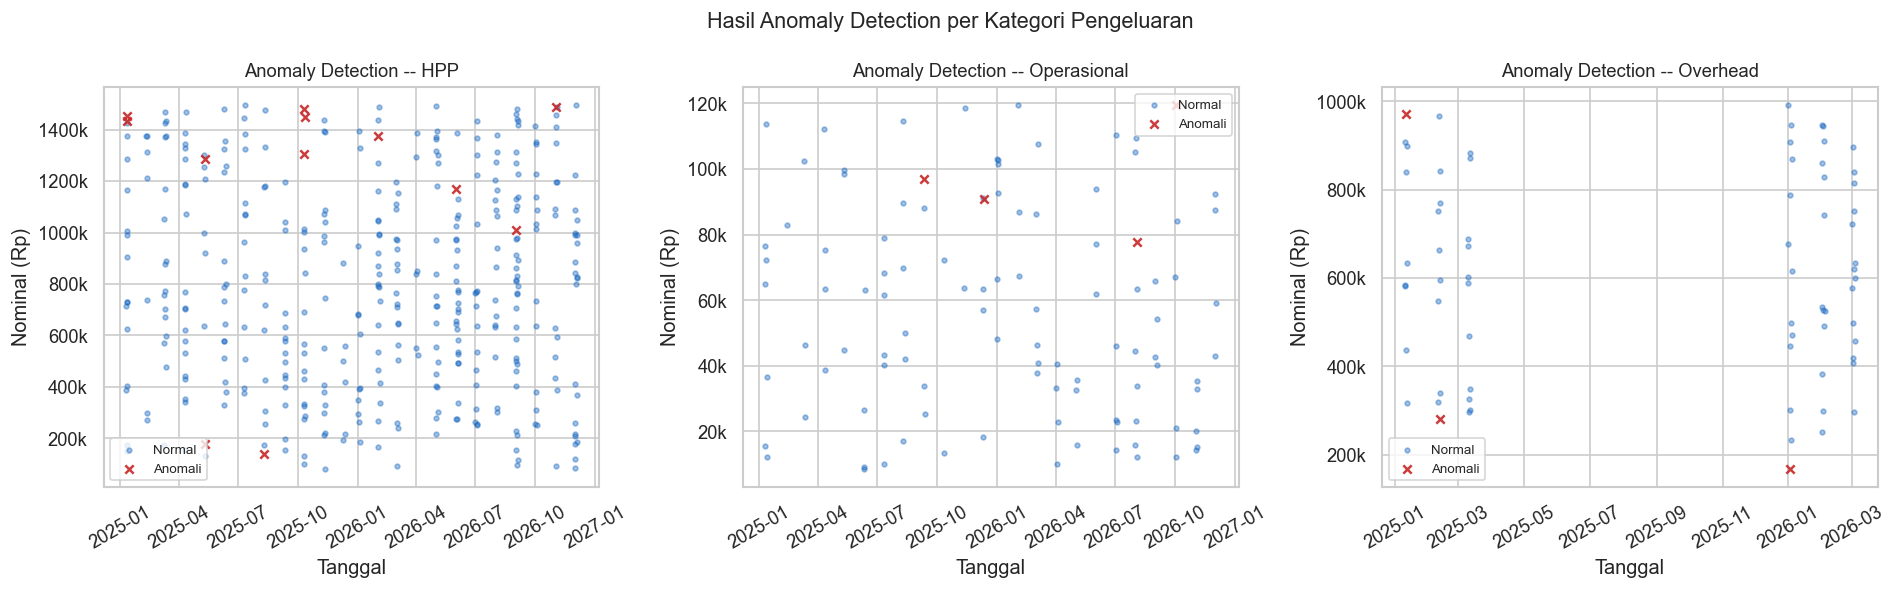

In [7]:
# Scatter plot: nominal vs anomaly score, warna berdasarkan is_anomaly
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, kat in enumerate(['HPP', 'Operasional', 'Overhead']):
    sub = df_keluar[df_keluar['kategori'] == kat]
    normal   = sub[sub['is_anomaly'] == 0]
    anomali  = sub[sub['is_anomaly'] == 1]

    axes[i].scatter(normal['tanggal'],  normal['nominal'],  s=8,  color='#1565C0', alpha=0.4, label='Normal')
    axes[i].scatter(anomali['tanggal'], anomali['nominal'], s=25, color='#C62828', alpha=0.9, label='Anomali', marker='x', linewidths=1.5)
    axes[i].set_title(f'Anomaly Detection -- {kat}', fontsize=11)
    axes[i].set_xlabel('Tanggal')
    axes[i].set_ylabel('Nominal (Rp)')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

plt.suptitle('Hasil Anomaly Detection per Kategori Pengeluaran', fontsize=13)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/anomaly_detection_plot.png', dpi=150, bbox_inches='tight')
plt.show()

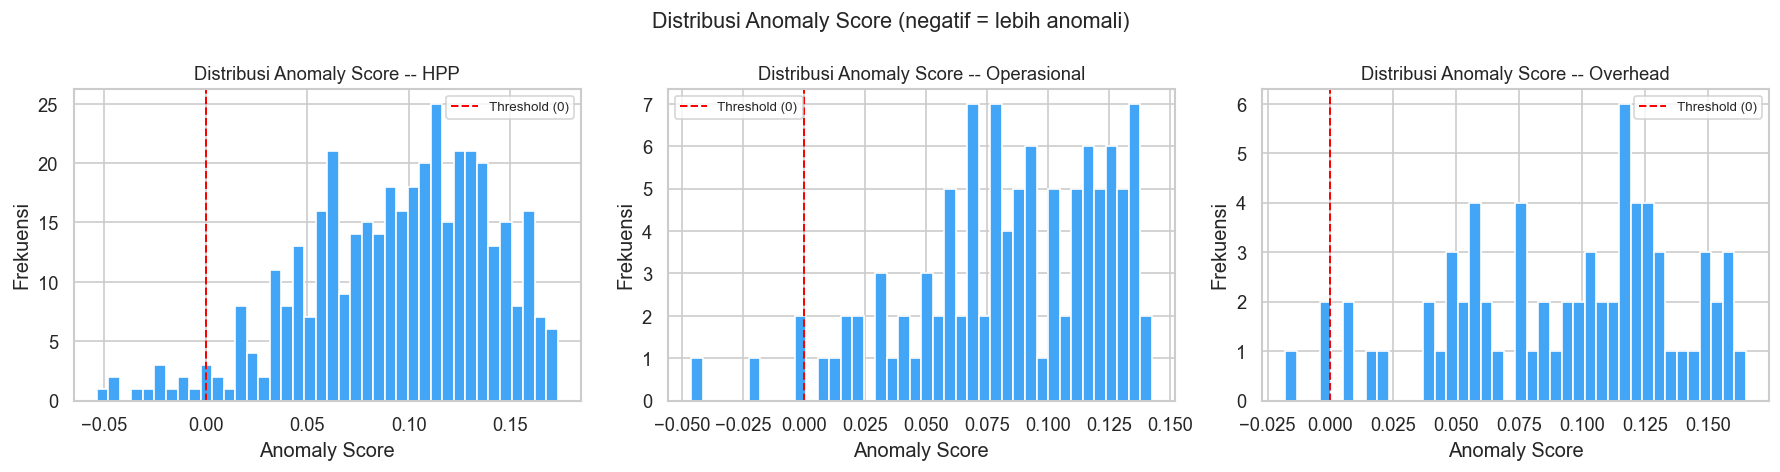

In [8]:
# Distribusi anomaly score per kategori
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, kat in enumerate(['HPP', 'Operasional', 'Overhead']):
    sub = df_keluar[df_keluar['kategori'] == kat]
    axes[i].hist(sub['anomaly_score'], bins=40, color='#42A5F5', edgecolor='white')
    axes[i].axvline(x=0, color='red', linestyle='--', linewidth=1.2, label='Threshold (0)')
    axes[i].set_title(f'Distribusi Anomaly Score -- {kat}', fontsize=11)
    axes[i].set_xlabel('Anomaly Score')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Anomaly Score (negatif = lebih anomali)', fontsize=13)
plt.tight_layout()
plt.show()


## 8. Inspeksi Transaksi Anomali

In [9]:
df_anomali = df_keluar[df_keluar['is_anomaly'] == 1].sort_values('anomaly_score')

print(f'Total transaksi anomali terdeteksi: {len(df_anomali)}')
print(f'Distribusi per kategori:')
print(df_anomali['kategori'].value_counts())

print('\nTop 10 transaksi paling anomali (skor terendah):')
cols_tampil = ['id_transaksi', 'id_warung', 'tanggal', 'kategori', 'nominal', 'rolling_mean_7d', 'anomaly_score', 'catatan']
display(df_anomali[cols_tampil].head(10))

Total transaksi anomali terdeteksi: 19
Distribusi per kategori:
kategori
HPP            12
Operasional     4
Overhead        3
Name: count, dtype: int64

Top 10 transaksi paling anomali (skor terendah):


,id_transaksi,id_warung,tanggal,kategori,nominal,rolling_mean_7d,anomaly_score,catatan
13202,F0B87A77-CE6,WRG-005,2025-10-10,HPP,1304745.0000,534608.8571,-0.0536,Beli minyak goreng 1 karton
6423,7034D7E5-5EE,WRG-004,2026-08-03,Operasional,77849.0000,34772.7143,-0.0463,Beli baterai timbangan
4001,21DC3555-D8B,WRG-005,2026-06-01,HPP,1167503.0000,495818.8571,-0.0432,NaN
13152,112A6722-307,WRG-003,2025-08-10,HPP,140669.0000,962290.1429,-0.0430,Beli aqua 1 karton
9831,46EC7C8F-4AA,WRG-005,2025-01-12,HPP,1433329.0000,1442834.5000,-0.0357,Beli detergen & sabun
1826,FD3021B0-426,WRG-004,2025-10-12,HPP,1447249.0000,609812.5714,-0.0267,Beli minyak goreng 1 karton
995,97E2EFAA-8EF,WRG-002,2025-10-11,HPP,1481949.0000,674750.1429,-0.0250,Ambil indomie 2 dus ke distributor
1567,4334C3ED-11D,WRG-005,2025-01-12,HPP,1452340.0000,1452340.0000,-0.0229,Restok gula & tepung
11998,75EAE35E-4CE,WRG-005,2025-05-12,HPP,1287183.0000,585115.7143,-0.0206,Beli aqua 1 karton
2359,ADB26A94-AAB,WRG-001,2025-09-11,Operasional,96875.0000,43547.5714,-0.0205,Ongkos kirim barang dari distributor


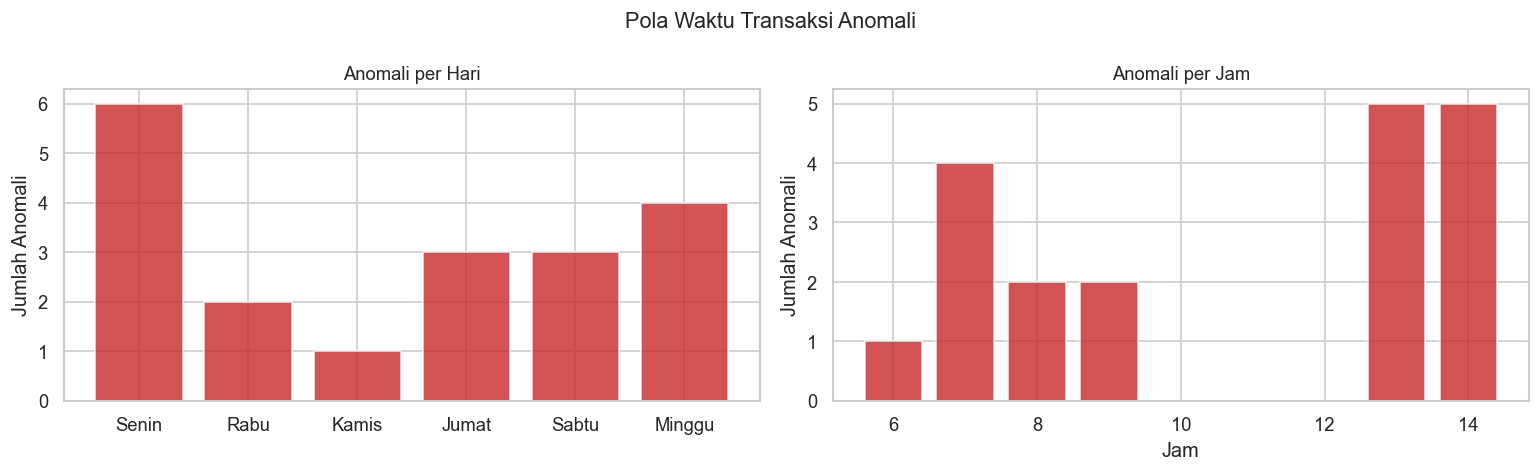

In [10]:
# Analisis pola anomali: hari apa dan jam berapa paling banyak anomali?
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

label_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
per_hari   = df_anomali['hari_dalam_minggu'].value_counts().sort_index()
axes[0].bar(
    [label_hari[i] for i in per_hari.index],
    per_hari.values,
    color='#C62828', alpha=0.8
)
axes[0].set_title('Anomali per Hari', fontsize=11)
axes[0].set_ylabel('Jumlah Anomali')

per_jam = df_anomali['jam_encoded'].value_counts().sort_index()
axes[1].bar(per_jam.index.astype(int), per_jam.values, color='#C62828', alpha=0.8)
axes[1].set_title('Anomali per Jam', fontsize=11)
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('Jumlah Anomali')

plt.suptitle('Pola Waktu Transaksi Anomali', fontsize=13)
plt.tight_layout()
plt.show()


## 9. Evaluasi Model

In [11]:
# Catatan: Isolation Forest adalah unsupervised model, tidak ada ground truth label
# Evaluasi dilakukan secara kualitatif dan dengan cek statistik

print('==== EVALUASI MODEL ANOMALY DETECTION ====')
print(f'Contamination parameter: {CONTAMINATION} ({CONTAMINATION*100:.0f}%)')
print()

for kat in ['HPP', 'Operasional', 'Overhead']:
    sub        = df_keluar[df_keluar['kategori'] == kat]
    n_total    = len(sub)
    n_anomali  = sub['is_anomaly'].sum()
    pct        = n_anomali / n_total * 100

    median_normal  = sub[sub['is_anomaly'] == 0]['nominal'].median()
    median_anomali = sub[sub['is_anomaly'] == 1]['nominal'].median()

    print(f'Kategori {kat}:')
    print(f'  Total transaksi  : {n_total:,}')
    print(f'  Anomali          : {n_anomali} ({pct:.1f}%)')
    print(f'  Median normal    : Rp{median_normal:,.0f}')
    print(f'  Median anomali   : Rp{median_anomali:,.0f}')
    print(f'  Rasio            : {median_anomali/median_normal:.1f}x lebih tinggi')
    print()

==== EVALUASI MODEL ANOMALY DETECTION ====
Contamination parameter: 0.03 (3%)

Kategori HPP:
  Total transaksi  : 399
  Anomali          : 12 (3.0%)
  Median normal    : Rp768,501
  Median anomali   : Rp1,339,550
  Rasio            : 1.7x lebih tinggi

Kategori Operasional:
  Total transaksi  : 104
  Anomali          : 4 (3.8%)
  Median normal    : Rp52,181
  Median anomali   : Rp93,780
  Rasio            : 1.8x lebih tinggi

Kategori Overhead:
  Total transaksi  : 70
  Anomali          : 3 (4.3%)
  Median normal    : Rp602,913
  Median anomali   : Rp281,488
  Rasio            : 0.5x lebih tinggi




## 10. Export Model

In [12]:
# Simpan model per kategori
for kat in ['HPP', 'Operasional', 'Overhead']:
    joblib.dump(models[kat],  f'{MODEL_DIR}/iforest_{kat.lower()}.pkl')
    joblib.dump(scalers[kat], f'{MODEL_DIR}/scaler_anomaly_{kat.lower()}.pkl')

# Simpan label encoder
joblib.dump(le_kategori, f'{MODEL_DIR}/le_kategori_anomaly.pkl')

# Simpan metadata model
metadata = {
    'contamination': CONTAMINATION,
    'fitur_cols': fitur_cols,
    'kategori_list': ['HPP', 'Operasional', 'Overhead'],
    'threshold': 0,  # anomaly_score < 0 = anomali
    'catatan': 'Model dilatih per kategori. Input wajib: nominal, hari_dalam_minggu, jam_encoded, rolling_mean_7d, rasio_vs_baseline'
}
with open(f'{MODEL_DIR}/anomaly_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Simpan hasil deteksi
df_keluar[[
    'id_transaksi', 'id_warung', 'tanggal', 'kategori',
    'nominal', 'rolling_mean_7d', 'rasio_vs_baseline',
    'anomaly_score', 'is_anomaly', 'catatan'
]].to_csv(f'{MODEL_DIR}/anomaly_hasil_deteksi.csv', index=False)

print('Model berhasil disimpan:')
for kat in ['hpp', 'operasional', 'overhead']:
    print(f'  {MODEL_DIR}/iforest_{kat}.pkl')
    print(f'  {MODEL_DIR}/scaler_anomaly_{kat}.pkl')
print(f'  {MODEL_DIR}/le_kategori_anomaly.pkl')
print(f'  {MODEL_DIR}/anomaly_metadata.json')
print(f'  {MODEL_DIR}/anomaly_hasil_deteksi.csv')

Model berhasil disimpan:
  ./models/iforest_hpp.pkl
  ./models/scaler_anomaly_hpp.pkl
  ./models/iforest_operasional.pkl
  ./models/scaler_anomaly_operasional.pkl
  ./models/iforest_overhead.pkl
  ./models/scaler_anomaly_overhead.pkl
  ./models/le_kategori_anomaly.pkl
  ./models/anomaly_metadata.json
  ./models/anomaly_hasil_deteksi.csv



## 11. Inference Function (untuk handover ke AI/Cloud)

In [13]:
def predict_anomaly(transaksi_list: list, model_dir: str = './models') -> list:
    """
    Inference function untuk Anomaly Detection.

    Parameters
    ----------
    transaksi_list : list of dict
        Setiap dict harus berisi:
        - id_transaksi        : str
        - kategori            : str  (HPP / Operasional / Overhead)
        - nominal             : float
        - hari_dalam_minggu   : int  (0=Senin, 6=Minggu)
        - jam_encoded         : int  (0-23)
        - rolling_mean_7d     : float  (rata-rata 7 hari sebelumnya, dihitung dari BE)
        - rasio_vs_baseline   : float  (nominal / rolling_mean_7d)

    Returns
    -------
    list of dict
        Setiap dict berisi id_transaksi, kategori, nominal, anomaly_score, is_anomaly
    """
    with open(f'{model_dir}/anomaly_metadata.json') as f:
        meta = json.load(f)

    fitur = meta['fitur_cols']
    threshold = meta['threshold']

    df_input = pd.DataFrame(transaksi_list)
    hasil = []

    for kat in meta['kategori_list']:
        sub_idx = df_input[df_input['kategori'] == kat].index
        if len(sub_idx) == 0:
            continue

        iforest = joblib.load(f'{model_dir}/iforest_{kat.lower()}.pkl')
        scaler  = joblib.load(f'{model_dir}/scaler_anomaly_{kat.lower()}.pkl')

        X = df_input.loc[sub_idx, fitur].fillna(0).values
        X_scaled = scaler.transform(X)
        scores   = iforest.decision_function(X_scaled)

        for i, idx in enumerate(sub_idx):
            row = df_input.loc[idx]
            hasil.append({
                'id_transaksi':  row.get('id_transaksi', f'TRX-{idx}'),
                'kategori':      kat,
                'nominal':       row['nominal'],
                'anomaly_score': float(scores[i]),
                'is_anomaly':    int(scores[i] < threshold),
            })

    return hasil


# Test inference
test_input = [
    {'id_transaksi': 'TRX-001', 'kategori': 'HPP',         'nominal': 250000,  'hari_dalam_minggu': 0, 'jam_encoded': 7,  'rolling_mean_7d': 230000, 'rasio_vs_baseline': 1.09},
    {'id_transaksi': 'TRX-002', 'kategori': 'HPP',         'nominal': 5000000, 'hari_dalam_minggu': 3, 'jam_encoded': 22, 'rolling_mean_7d': 230000, 'rasio_vs_baseline': 21.7},
    {'id_transaksi': 'TRX-003', 'kategori': 'Operasional', 'nominal': 45000,   'hari_dalam_minggu': 1, 'jam_encoded': 8,  'rolling_mean_7d': 40000,  'rasio_vs_baseline': 1.12},
    {'id_transaksi': 'TRX-004', 'kategori': 'Overhead',    'nominal': 500000,  'hari_dalam_minggu': 0, 'jam_encoded': 9,  'rolling_mean_7d': 450000, 'rasio_vs_baseline': 1.11},
]

hasil_test = predict_anomaly(test_input)
print('Hasil inference test:')
for h in hasil_test:
    status = 'ANOMALI' if h['is_anomaly'] else 'Normal'
    print(f"  {h['id_transaksi']} | {h['kategori']:12s} | Rp{h['nominal']:>10,.0f} | Score: {h['anomaly_score']:+.4f} | {status}")

Hasil inference test:
  TRX-001 | HPP          | Rp   250,000 | Score: +0.0162 | Normal
  TRX-002 | HPP          | Rp 5,000,000 | Score: -0.0944 | ANOMALI
  TRX-003 | Operasional  | Rp    45,000 | Score: +0.0806 | Normal
  TRX-004 | Overhead     | Rp   500,000 | Score: +0.0514 | Normal
